In [ ]:
!pip install -U transformers datasets peft bitsandbytes accelerate scikit-learn scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 91.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 33.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 106.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 58.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.7/536.7 kB 36.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.18.1 requires scipy<1.17,>=1.8, but you have s

In [5]:
import json
import os
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import KBinsDiscretizer
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, 
    AutoModelForCausalLM, 
    BitsAndBytesConfig, 
    TrainingArguments, 
    Trainer, 
    DataCollatorForSeq2Seq
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
from huggingface_hub import login, HfApi
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# --- 2. CONFIGURATION ---

In [8]:
MODEL_ID = "Qwen/Qwen2.5-Coder-7B-Instruct"
OUTPUT_DIR = "postgres_tuner_adapter"

N_BINS = 20  # Discretize knobs into 20 buckets for easier prediction

# Variables
dataset_files = [
    "job_combined_data.json",
    "ssb_combined_data.json",
    "tpcds_combined_data.json",
    "tpch_combined_data.json"
]
KNOB_CONFIG_FILE = "knob_config.json"
REPO_NAME = "NisithDissanayake/genknob-tuner"
HF_TOKEN = os.getenv("HF_TOKEN")
if not HF_TOKEN:
    raise ValueError("HF_TOKEN environment variable not set. Set it with: export HF_TOKEN='your_token_here'")

login(token=HF_TOKEN)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


# --- 3. DATA LOADING & PRE-PROCESSING ---

In [ ]:
print("Loading Data...")
all_data = []
for fpath in dataset_files:
    if os.path.exists(fpath):
        with open(fpath, 'r') as f:
            data = json.load(f)
            # Tag the source for tracking
            fname = fpath.split("/")[-1].replace("_combined_data.json", "")
            for d in data:
                d['source_benchmark'] = fname
            all_data.extend(data)
    else:
        print(f"Warning: File not found {fpath}, skipping...")

df = pd.DataFrame(all_data)
print(f"Loaded {len(df)} total workload samples.")

Loading Data...
Loaded 730 total workload samples.


# --- 4.BINNING ---

* LLMs struggle with raw floats like '13421.55'.
* We convert them to bins (0-19), so the LLM just has to pick the "Category".


In [ ]:
import pandas as pd
import json
from sklearn.preprocessing import KBinsDiscretizer

# 1. Load Knob Config to get Min/Max constraints
with open(KNOB_CONFIG_FILE, 'r') as f:
    knob_config = json.load(f)

# Normalize the config data from the dataframe
config_df = pd.json_normalize(df['best_config'])
knob_columns = config_df.columns.tolist()

print(f"Discretizing {len(knob_columns)} configuration knobs...")

# 2. Create Min and Max boundary rows
# This ensures the Discretizer "sees" the full theoretical range, not just observed data
min_constraints = {k: v['min'] for k, v in knob_config.items() if k in knob_columns}
max_constraints = {k: v['max'] for k, v in knob_config.items() if k in knob_columns}

min_df = pd.DataFrame([min_constraints])
max_df = pd.DataFrame([max_constraints])

# 3. Combine Data + Constraints for Fitting
# We fit on (Data + Min + Max) so bin edges stretch to cover the theoretical limits
fit_data = pd.concat([config_df, min_df, max_df], ignore_index=True)

# 4. Initialize and Fit Discretizer
# Quantile strategy is still used, but now it knows the boundaries
discretizer = KBinsDiscretizer(n_bins=N_BINS, encode='ordinal', strategy='quantile')
discretizer.fit(fit_data)

# 5. Transform ONLY the actual data (not the dummy rows)
config_binned = discretizer.transform(config_df)

# 6. Store bin edges with explicit Min/Max clamping
# We override the first and last edge to be exactly the Min/Max from config
# This is a safety measure for the "Decoder Ring"
bin_edges = {}
for i, col in enumerate(knob_columns):
    edges = discretizer.bin_edges_[i].copy()
    
    # Enforce strict theoretical limits on the edges
    if col in knob_config:
        edges[0] = min(edges[0], knob_config[col]['min'])
        edges[-1] = max(edges[-1], knob_config[col]['max'])
        
    bin_edges[col] = edges

# 7. Save discretized values back to data
binned_configs = []
for i in range(len(config_binned)):
    # Create a dictionary of {knob_name: bin_index}
    binned_configs.append({
        col: int(val) 
        for col, val in zip(knob_columns, config_binned[i])
    })

df['binned_config'] = binned_configs

print("Discretization complete. Edges respect knob_config limits.")

Discretizing 15 configuration knobs...


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 9 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 10 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small

In [7]:
print("Raw Config:")
print(df.iloc[0]['best_config'])
print("\nBinned Config:")
print(df.iloc[0]['binned_config'])

Raw Config:
{'shared_buffers': 1229044.0, 'work_mem': 31772.0, 'maintenance_work_mem': 136780.0, 'effective_cache_size': 2125691.0, 'max_connections': 442.0, 'wal_buffers': 7280.0, 'checkpoint_completion_target': 0.8606418371200562, 'checkpoint_timeout': 1101.0, 'effective_io_concurrency': 27.0, 'join_collapse_limit': 15.0, 'from_collapse_limit': 20.0, 'bgwriter_delay': 860.0, 'bgwriter_lru_multiplier': 1.7683191299438477, 'default_statistics_target': 196.0, 'max_parallel_workers_per_gather': 0.0}

Binned Config:
{'shared_buffers': 14, 'work_mem': 0, 'maintenance_work_mem': 0, 'effective_cache_size': 11, 'max_connections': 12, 'wal_buffers': 17, 'checkpoint_completion_target': 19, 'checkpoint_timeout': 11, 'effective_io_concurrency': 2, 'join_collapse_limit': 8, 'from_collapse_limit': 11, 'bgwriter_delay': 16, 'bgwriter_lru_multiplier': 3, 'default_statistics_target': 7, 'max_parallel_workers_per_gather': 0}


# --- 5. SPLITTING (Grouped by Workload) ---

In [8]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
df['group_id'] = df['source_benchmark'] + "_" + df['workload_idx'].astype(str)

train_idx, test_idx = next(splitter.split(df, groups=df['group_id']))
train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

print(f"Train Size: {len(train_df)} | Test Size: {len(test_df)}")

Train Size: 657 | Test Size: 73


# --- 6. PROMPT ENGINEERING (Qwen Format) ---

In [9]:
def format_instruction(row):
    # 1. Internal Metrics (The DB State)
    # Filter out zeros to save tokens, as 0 usually means "did not happen"
    metrics_str = "\n".join([f"- {k}: {v}" for k,v in row.get('internal_metrics', {}).items() if v > 0])
    
    # 2. Workload Features (The Query Logic: Read/Write ratio, Filter ratio, etc.)
    workload_str = "\n".join([f"- {k}: {v}" for k,v in row.get('workload_features', {}).items()])
    
    # 3. Query Plan Features (The Execution Structure)
    plan_str = "\n".join([f"- {k}: {v}" for k,v in row.get('query_plan_features', {}).items()])
    
    # Construct the User Prompt
    user_prompt = f"""You are an expert PostgreSQL DBA. Analyze the workload state, features, and query plans below.
Determine the optimal database configuration knobs to maximize performance.
Output the configuration as a JSON object where values are Bin Indices (0-{N_BINS-1}).

### Workload Context ({row.get('source_benchmark', 'Unknown')}):
**Internal Metrics (State):**
{metrics_str}

**Workload Features (Stats):**
{workload_str}

**Query Plan Signals (Structure):**
{plan_str}

### Task:
Predict the optimal configuration bucket for each knob.
"""
    
    # The Assistant response (The Target)
    target_json = json.dumps(row['binned_config'], indent=2)
    
    # Qwen Chat Template
    text = f"<|im_start|>system\nYou are a database tuning assistant.<|im_end|>\n<|im_start|>user\n{user_prompt}<|im_end|>\n<|im_start|>assistant\n{target_json}<|im_end|>"
    return text

train_df['text'] = train_df.apply(format_instruction, axis=1)
test_df['text'] = test_df.apply(format_instruction, axis=1)

# Convert to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df[['text']])
test_dataset = Dataset.from_pandas(test_df[['text']])

/tmp/ipykernel_55/2506103370.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['text'] = train_df.apply(format_instruction, axis=1)
/tmp/ipykernel_55/2506103370.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['text'] = test_df.apply(format_instruction, axis=1)


# --- 7. MODEL LOADING (4-bit QLoRA) ---

In [10]:
print("Loading Model in 4-bit...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

model.gradient_checkpointing_enable()
model = prepare_model_for_kbit_training(model)

Loading Model in 4-bit...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# --- 8. LoRA CONFIGURATION ---

In [11]:
peft_config = LoraConfig(
    r=64, 
    lora_alpha=128, 
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"], 
    lora_dropout=0.05, 
    bias="none", 
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

trainable params: 161,480,704 || all params: 7,777,097,216 || trainable%: 2.0764


# --- 9. TOKENIZATION ---

Measuring token lengths...
Max Length: 1276 tokens
Avg Length: 1043.2 tokens
95% of data is under: 1196 tokens


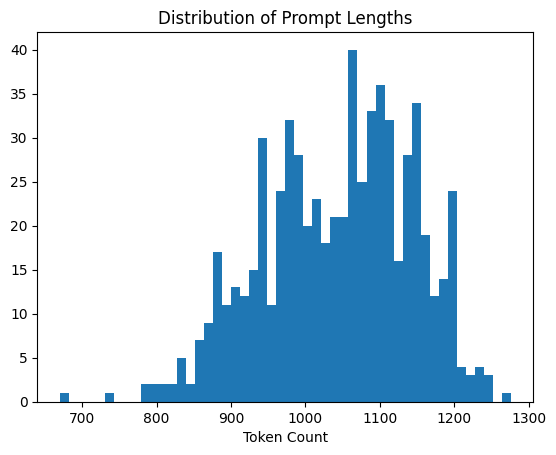

In [12]:
import matplotlib.pyplot as plt

# 1. Calculate lengths for every single row
print("Measuring token lengths...")
# We use the tokenizer purely to count, not to return tensors yet
lens = [len(tokenizer.encode(text)) for text in train_df['text']]

max_len = max(lens)
avg_len = sum(lens) / len(lens)
p95_len = sorted(lens)[int(0.95 * len(lens))] # 95th percentile

print(f"Max Length: {max_len} tokens")
print(f"Avg Length: {avg_len:.1f} tokens")
print(f"95% of data is under: {p95_len} tokens")

# 3. Visual Check
plt.hist(lens, bins=50)
plt.title("Distribution of Prompt Lengths")
plt.xlabel("Token Count")
plt.show()

In [13]:
MAX_SEQ_LENGTH = 1536  

In [14]:
def tokenize_function(examples):
    # 1. Tokenize the text
    model_inputs = tokenizer(
        examples["text"], 
        padding="max_length", 
        truncation=True, 
        max_length=MAX_SEQ_LENGTH
    )
    
    # 2. Create Labels (Clone of input_ids)
    model_inputs["labels"] = model_inputs["input_ids"].copy()
    
    # 3. Mask Padding Tokens in Labels
    # We replace the padding token ID with -100 so the loss function ignores them.
    # If we don't do this, the model tries to learn "how to predict empty space", which is bad.
    pad_token_id = tokenizer.pad_token_id
    
    # Iterate over every row in the batch
    for i in range(len(model_inputs["labels"])):
        # Replace pad_token_id with -100
        model_inputs["labels"][i] = [
            -100 if token == pad_token_id else token 
            for token in model_inputs["labels"][i]
        ]
        
    return model_inputs

print(">>> Tokenizing ...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

>>> Tokenizing ...


Map:   0%|          | 0/657 [00:00<?, ? examples/s]

Map:   0%|          | 0/73 [00:00<?, ? examples/s]

# --- 10. TRAINING ---


In [ ]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=1,      
    gradient_accumulation_steps=16,     
    learning_rate=2e-4,                
    num_train_epochs=3,                 
    fp16=True,                          
    logging_steps=10,
    save_strategy="epoch",              
    eval_strategy="epoch",        
    save_total_limit=2,                
    optim="paged_adamw_32bit",      
    report_to="none"
)

trainer = Trainer(
    model=model,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    args=training_args,
    data_collator=DataCollatorForSeq2Seq(tokenizer, pad_to_multiple_of=8, return_tensors="pt"),
)
model.gradient_checkpointing_enable()
print("Starting Training...")
trainer.train()

# --- 11. SAVE EVERYTHING ---


In [ ]:
print(f"Saving model to {OUTPUT_DIR}...")
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

import pickle
with open(f"{OUTPUT_DIR}/bin_edges.pkl", "wb") as f:
    pickle.dump(bin_edges, f)

print("Fine-Tuning Complete. Model and Bin-Decoders saved.")

In [ ]:
print(f"Pushing model to {REPO_NAME}...")

model.push_to_hub(REPO_NAME)
tokenizer.push_to_hub(REPO_NAME)

api = HfApi()
api.upload_file(
    path_or_fileobj=f"{OUTPUT_DIR}/bin_edges.pkl", 
    path_in_repo="bin_edges.pkl",                  
    repo_id=REPO_NAME,
    repo_type="model"
)

print("Success! Model and Artifacts are live on Hugging Face.")

# --- 12. INFERENCE ---

In [ ]:
# def predict_config(workload_sample):
#     # 1. Format Prompt
#     prompt = format_instruction(workload_sample).split("<|im_start|>assistant")[0] + "<|im_start|>assistant\n"
#     inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
#     # 2. Generate
#     with torch.no_grad():
#         outputs = model.generate(**inputs, max_new_tokens=512, temperature=0.1)
    
#     # 3. Decode Text
#     response = tokenizer.decode(outputs[0], skip_special_tokens=True)
#     try:
#         # Extract JSON part
#         json_str = response.split("assistant")[-1].strip()
#         pred_bins = json.loads(json_str)
        
#         # 4. Decode Bins back to Real Values (The "Un-Binning")
#         real_config = {}
#         for knob, bin_idx in pred_bins.items():
#             # Get the edges for this knob
#             edges = bin_edges[knob]
#             # Simple decoding: take the midpoint of the bin
#             # Safety check for index out of bounds
#             idx = min(max(int(bin_idx), 0), len(edges)-2)
#             lower = edges[idx]
#             upper = edges[idx+1]
#             real_config[knob] = (lower + upper) / 2
            
#         return real_config
#     except:
#         return "Error parsing output"

# # Test on one sample
# print("\n>>> Testing Inference on unseen data...")
# sample_row = test_df.iloc[0]
# predicted = predict_config(sample_row)
# print("Predicted Configuration (Real Values):")
# print(predicted)